<div class="alert alert-info"> <b>Комментарий студента:</b> Добрый день(Привет!), меня зовут Оксана. Это мой проект.</div>

## Описание проекта:
  * Вы — аналитик крупного интернет-магазина. Вместе с отделом маркетинга вы подготовили список гипотез для увеличения выручки.
  * Приоритизируйте гипотезы, запустите A/B-тест и проанализируйте результаты.
  * Часть 1. Приоритизация гипотез.
В файле /datasets/hypothesis.csv 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.
   - Задача:
    - Примените фреймворк ICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
    - Примените фреймворк RICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
    - Укажите, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объясните, почему так произошло.

* Часть 2. Анализ A/B-теста
Вы провели A/B-тест и получили результаты, которые описаны в файлах /datasets/orders.csv и /datasets/visitors.csv.
   - Задача:
     - Проанализируйте A/B-тест:
     1. Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения.
     2. Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.
     3. Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.
     4. Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.
     5. Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.
     6. Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.
     7. Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.
     8. Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.
     9. Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.
     10. Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.
     11. Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.
     12. Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.
     13. Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.
     14. Примите решение по результатам теста и объясните его. Варианты решений:
        1. Остановить тест, зафиксировать победу одной из групп.
        2. Остановить тест, зафиксировать отсутствие различий между группами.
        3. Продолжить тест.

## Описание данных:
* Данные для первой части
Файл /datasets/hypothesis.csv. Скачать датасет
 * Hypothesis — краткое описание гипотезы;
 * Reach — охват пользователей по 10-балльной шкале;
 * Impact — влияние на пользователей по 10-балльной шкале;
 * Confidence — уверенность в гипотезе по 10-балльной шкале;
 * Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.
* Данные для второй части
Файл /datasets/orders.csv. Скачать датасет
 * transactionId — идентификатор заказа;
 * visitorId — идентификатор пользователя, совершившего заказ;
 * date — дата, когда был совершён заказ;
 * revenue — выручка заказа;
 * group — группа A/B-теста, в которую попал заказ.
* Файл /datasets/visitors.csv. Скачать датасет
 * date — дата;
 * group — группа A/B-теста;
 * visitors — количество пользователей в указанную дату в указанной группе A/B-теста

Проделаем работу:
 * Загрузим данные и подготовим их к анализу
 * Часть 1. Приоритизация гипотез.
 * Часть 2. Анализ A/B-теста


## Загрузите данные и подготовьте их к анализу

Загрузите данные о визитах, заказах и рекламных расходах из CSV-файлов в переменные.

**Пути к файлам**

- гипотезы: `/datasets/hypothesis.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/hypothesis.csv);
- заказы: `/datasets/orders.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/orders.csv);
- визиты: `/datasets/visitors.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/hypothesis.csv);

Изучите данные и выполните предобработку


In [1]:
# импортируем нужные библиотеки
import pandas as pd
import scipy.stats as stats
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as stp
import warnings

warnings.filterwarnings("ignore")  # бережем глаза от ненужных предупреждений


In [2]:
# загружаем данные
try:
    visits = pd.read_csv('/datasets/visitors.csv')
    orders = pd.read_csv('/datasets/orders.csv')
    hypothesis = pd.read_csv('/datasets/hypothesis.csv')
except:
    visits = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv')
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv')
    hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv')


In [3]:
# выведим на экран
visits.head(5)

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [4]:
# выведим на эксран инфо датафрема
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [5]:
# выведим на экран
orders.head(5)

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [6]:
# выведим на эксран инфо датафрема
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [7]:
# выведим на экран
hypothesis.head(5)

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


In [8]:
# выведим на эксран инфо датафрема
hypothesis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [9]:
# приведем к нижнему регистру таблицу hypothesis
hypothesis.columns = hypothesis.columns.str.lower()
# выведим на экран
hypothesis.head(5)

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


In [10]:
# приводим данные о времени к формату datetime
visits['date'] = pd.to_datetime(visits['date'])
orders['date'] = pd.to_datetime(orders['date'])

In [11]:
# проверим дубликаты
visits.duplicated().sum()


0

In [12]:
# проверим дубликаты
orders.duplicated().sum()


0

In [13]:
# проверим дубликаты
hypothesis.duplicated().sum()

0

In [14]:
# выведим не явные дубликаты кол-во
orders[orders.duplicated(['group', 'visitorId'])].count()

transactionId    108
visitorId        108
date             108
revenue          108
group            108
dtype: int64

In [15]:
# выведим на экран неявные дубликаты по дате пользователю и группе
orders[orders.duplicated(['group', 'visitorId'])].sort_values(by ='date' , ascending = False )

,transactionId,visitorId,date,revenue,group
1015,4262851755,1294878855,2019-08-31,570,A
1018,1415970216,4256040402,2019-08-31,5170,A
1019,453824282,4256040402,2019-08-31,1850,B
757,461722689,2988190573,2019-08-30,24860,A
793,4080243878,2988190573,2019-08-30,20290,A
...,...,...,...,...,...
147,52260954,3967698036,2019-08-01,990,A
145,735232225,611059232,2019-08-01,8800,A
144,365058890,611059232,2019-08-01,2750,A
112,1638982251,3062433592,2019-08-01,8470,B


In [16]:
# групируем что бы вывести пользователей c количеством групп
groupId = orders.groupby('visitorId')['group'].nunique()
groupId

visitorId
5114589       1
6958315       1
8300375       2
11685486      1
39475350      1
             ..
4266935830    2
4278982564    1
4279090005    1
4281247801    1
4283872382    1
Name: group, Length: 1031, dtype: int64

In [17]:
# подгрузим к каждому пользователю количество групп 
orders = orders.merge(groupId, on=["visitorId", "visitorId"])

orders

,transactionId,visitorId,date,revenue,group_x,group_y
0,3667963787,3312258926,2019-08-15,1650,B,1
1,2804400009,3642806036,2019-08-15,730,B,1
2,2961555356,4069496402,2019-08-15,400,A,2
3,1473132782,4069496402,2019-08-12,640,B,2
4,3797467345,1196621759,2019-08-15,9759,B,1
...,...,...,...,...,...,...
1192,3592955527,608641596,2019-08-14,16490,B,1
1193,2662137336,3733762160,2019-08-14,6490,B,1
1194,2203539145,370388673,2019-08-14,3190,A,1
1195,1807773912,573423106,2019-08-14,10550,A,1


In [18]:
# переименнуем столбец group_x обратно в group
orders = orders.rename(columns={'group_x': 'group'})

In [19]:
# выведим пользователей котрые попали в 2 группы
vis2 = orders[orders['group_y'] == 2]
vis2['visitorId'].unique()

array([4069496402,  963407295,  351125977, 3234906277,  199603092,
        237748145, 3803269165, 2038680547, 2378935119, 4256040402,
       2712142231,    8300375,  276558944,  457167155, 3062433592,
       1738359350, 2458001652, 2716752286, 3891541246, 1648269707,
       3656415546, 2686716486, 2954449915, 2927087541, 2579882178,
       3957174400, 2780786433, 3984495233,  818047933, 1668030113,
       3717692402, 2044997962, 1959144690, 1294878855, 1404934699,
       2587333274, 3202540741, 1333886533, 2600415354, 3951559397,
        393266494, 3972127743, 4120364173, 4266935830, 1230306981,
       1614305549,  477780734, 1602967004, 1801183820, 4186807279,
       3766097110, 3941795274,  471551937, 1316129916,  232979603,
       2654030115, 3963646447, 2949041841])

In [20]:
# сколько пользователей попали одновременно в обе группы:
orders.groupby('visitorId').agg({'group' : 'nunique'}).query('group>1').count()

group    58
dtype: int64

### Выовд: 
  - данные нормальные
  - привели название столбцов к нижнему регистру
  - изменили тип даты datetime
  - явных дубликатов нет
  - неявные дубликаты, есть
  - 58 пользователей попали в обе группы A и B
    

<div class="alert alert-info"> <b>Комментарий студента:</b> Выявила неявные дубликаты. Удалять нельзя, график в дальнейшем сьехали. Получается нужна группу пересвоить?</div>
    

<div class="alert alert-info"> <b>Комментарий студента:</b> Я что то не поняла. распределение групп было каждый день. пользователи могли попасть в ту и другую групу но в разные дни? </div>

## Часть 1. Приоритизация гипотез.

В файле /datasets/hypothesis.csv 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.
- Задача
  - Примените фреймворк ICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
  - Примените фреймворк RICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
  - Укажите, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объясните, почему так произошло.

### Примените фреймворк ICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.

In [21]:
# опция что бы выводился весь текст 
pd.options.display.max_colwidth = 140
hypothesis

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


In [22]:
# посчитайем ICE для гипотез.
hypothesis['ICE'] = round(((hypothesis['impact']*hypothesis['confidence'])/hypothesis['efforts']).astype('float'),2)

# выыедим на экран
display(hypothesis[['hypothesis','ICE']].sort_values(by = 'ICE' , ascending=False))


,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


#### По фреймворку ICE приорететнее оказались 3 гипотезы:

- Запустить акцию, дающую скидку на товар в день рождения
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

### Примените фреймворк RICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.

In [23]:
# посчитайем RICE для гипотез.
hypothesis['RICE'] = (hypothesis['reach']*hypothesis['impact']*hypothesis['confidence']/hypothesis['efforts']).astype('float')

# выведим на экран
display(hypothesis[['hypothesis','RICE']].sort_values(by ='RICE' , ascending = False ))

,hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0


#### По фреймворку RICE приорететнее оказались 3 гипотезы:

- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

### Вывод:
- приоритизация изменилась, так как параметр Reach, который отвечает за охват аудитории, оказался выше у лидирующих гипотез по фреймворку RICE.

## Часть 2. Анализ A/B-теста

Вы провели A/B-тест и получили результаты, которые описаны в файлах /datasets/orders.csv и /datasets/visitors.csv.
   - Задача:
     - Проанализируйте A/B-тест:
     1. Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения.
     2. Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.
     3. Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.
     4. Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.
     5. Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.
     6. Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.
     7. Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.
     8. Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.
     9. Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.
     10. Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.
     11. Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.
     12. Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.
     13. Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.
     14. Примите решение по результатам теста и объясните его. Варианты решений:
        1. Остановить тест, зафиксировать победу одной из групп.
        2. Остановить тест, зафиксировать отсутствие различий между группами.
        3. Продолжить тест.

### Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения.

In [24]:
#vсоздаем массив уникальных пар значений дат и групп теста
datesGroups = orders[['date','group']].drop_duplicates()


In [25]:
#vполучаем агрегированные кумулятивные по дням данные о заказах 
ordersAggregated = datesGroups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]\
.agg({'date' : 'max', 'group' : 'max', 'transactionId' : 'nunique', 'visitorId' : 'nunique', 'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])


In [26]:
#vполучаем агрегированные кумулятивные по дням данные о посетителях
visitorsAggregated = datesGroups.apply(lambda x: visits[np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), axis=1).sort_values(by=['date','group'])


In [27]:
#vобъединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
display(cumulativeData.head(5))

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845


In [28]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]



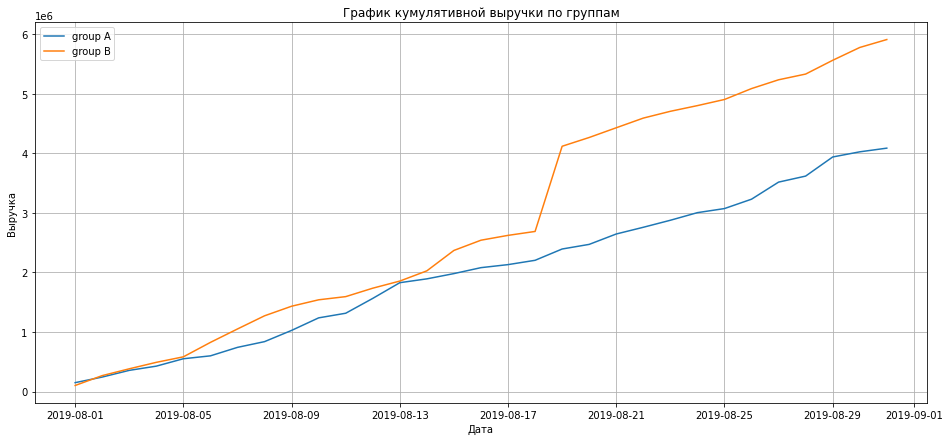

In [29]:
# построим графики
plt.figure(figsize=(16, 7))

# cтроим график выручки группы А
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='group A')

# cтроим график выручки группы B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='group B')

plt.title('График кумулятивной выручки по группам')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.grid()
plt.legend()
plt.show()

#### Вывод:
до 13.08.2019 распределение было равномерным, после выручка по группе Б стала рости. Это может быть связанно с ростом заказов приближающемуся к 1 сентября.

### Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.

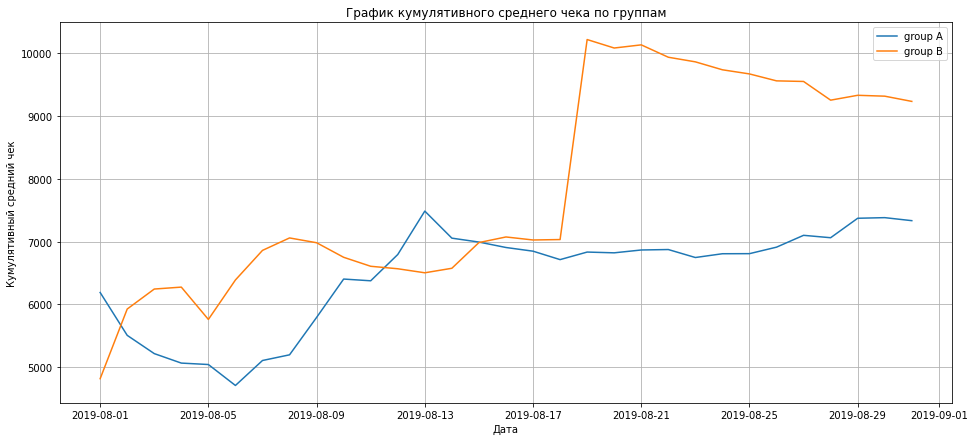

In [30]:
# построим графики
plt.figure(figsize=(16, 7))

# cтроим график среднего чека группы А
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='group A')

# cтроим график среднего чека группы B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='group B')

plt.title('График кумулятивного среднего чека по группам')
plt.xlabel('Дата')
plt.ylabel('Кумулятивный cредний чек')
plt.grid()
plt.legend()
plt.show()

#### Вывод:
- Кумулятивный средний чек группы А имеет более плавный график, в отличии от группы B
- Кумулятивный средний чек группы B имеет рост в середине теста между 17 и 21 числом. Скорее всего, в эту дату произошли очень крупные покупки.
- Кумулятивное значение среднего чека каждой группы стабилизируется к концу теста.

### Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.

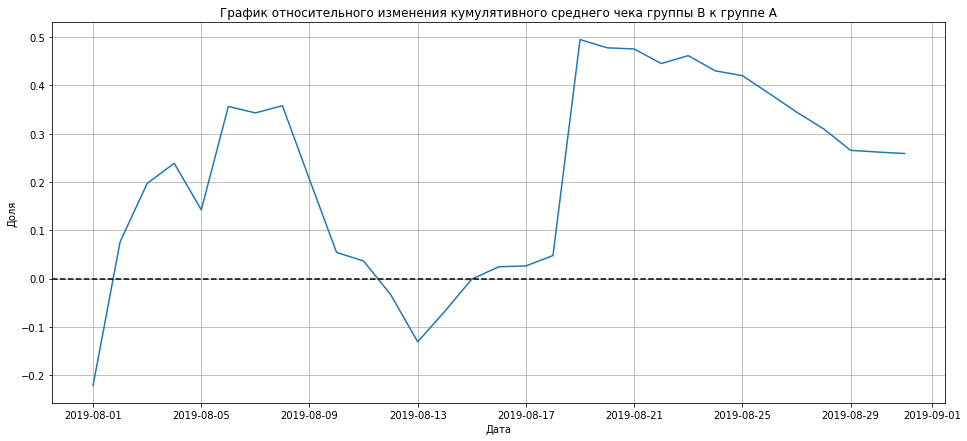

In [31]:
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# построим график
plt.figure(figsize=(16, 7))

# cтроим отношение средних чеков
plt.plot(mergedCumulativeRevenue['date'],
 (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()
plt.show()

#### Вывод:
 - На графике резкие изменения среднего чека, скорее всего возможно были сделаны заказы с большим средним чеком
 - результаты теста резко меняется, это говорит о том что были совершены аномальные заказы

<div class="alert alert-info"> <b>Комментарий студента:</b> Допонила</div>

### Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.

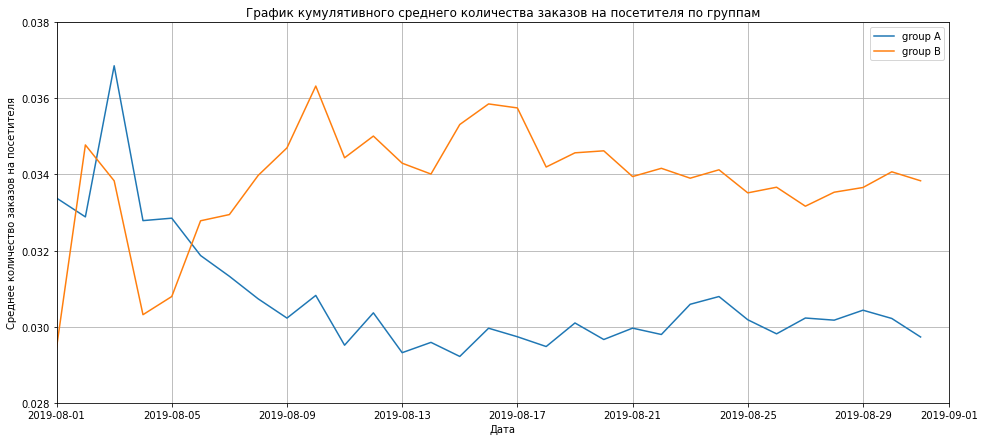

In [32]:
# считаем кумулятивную среднего количества заказов на посетителя по группам
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# строим графики
plt.figure(figsize=(16, 7))

# строим отношение к группе A
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='group A')
# строим отношение к группе B
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='group B')

plt.axis([dt.datetime(2019, 8, 1), dt.datetime(2019, 9, 1), 0.028, 0.038])
plt.title('График кумулятивного среднего количества заказов на посетителя по группам')
plt.xlabel('Дата')
plt.ylabel('Cреднее количество заказов на посетителя')
plt.legend()
plt.grid()
plt.show()

#### Вывод:
  - с 01 по 05/08 конверсия была выше у группы А, далее конверия стала равномерной и группа B стала выша A  

### Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.

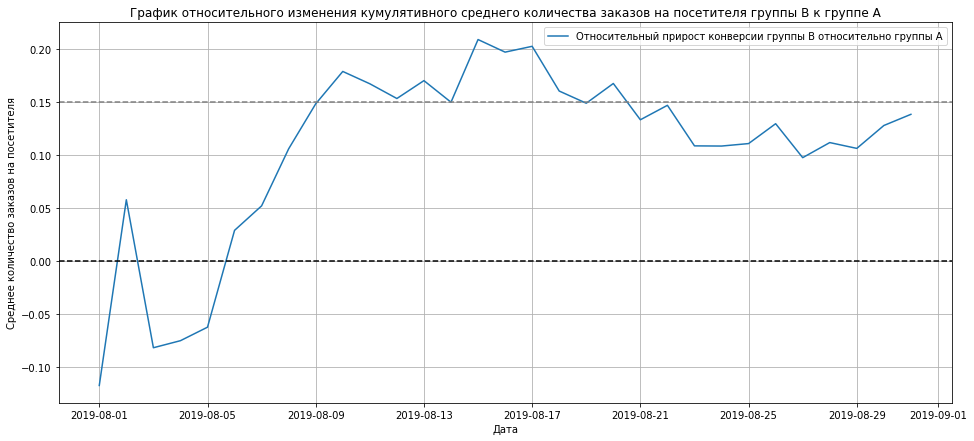

In [33]:
# собираем данные в одном датафрейме
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

#строим график
plt.figure(figsize=(16, 7))

# строим отношение 
plt.plot(mergedCumulativeConversions['date'], mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1, label="Относительный прирост конверсии группы B относительно группы A")

# добавляем оси
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--')
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Среднее количество заказов на посетителя')
plt.legend()
plt.grid()
plt.show()

#### Вывод:
 - группа B выходит вперед после 5-го дня теста и лидирует с преимуществом примерно 15% до конца теста.

### Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.

In [34]:
# подсчитаем количество заказов по пользователям
ordersByUsers = (
    orders.groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
)
# переименнуем столбец
ordersByUsers.columns = ['visitorId', 'transactionId']

# выведим на экран
display(ordersByUsers.sort_values(by='transactionId', ascending=False).head(10))

,visitorId,transactionId
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


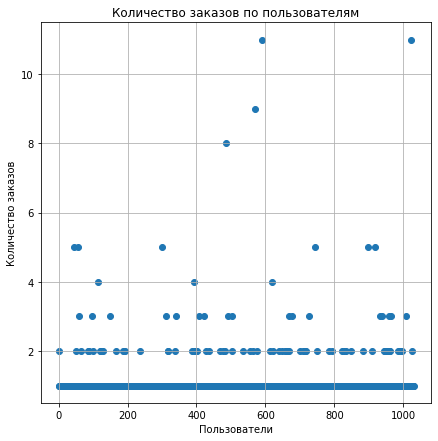

In [35]:
# построим точечный график

x_values = pd.Series(range(0, len(ordersByUsers)))
plt.figure(figsize=(7, 7))
plt.scatter(x_values, ordersByUsers['transactionId'])
plt.xlabel('Пользователи')
plt.ylabel('Количество заказов')
plt.title("Количество заказов по пользователям")
plt.grid()
plt.show()

#### Вывод:
  - Основная масса сделали по 1 заказу, там где по 2 и более могут быть аномальными

### Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей

In [36]:
np.percentile(ordersByUsers['transactionId'], [95, 99])

array([2., 4.])

#### Вывод:
   - Не более 5% пользователей оформляли больше 2-х заказов, 1% пользователей заказывали больше 4-х раз.

### Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.

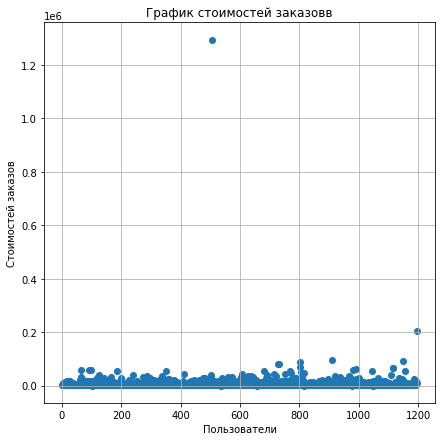

In [37]:
# построим точечный график
x_values = pd.Series(range(0, len(orders['revenue'])))
plt.figure(figsize=(7, 7))
plt.scatter(x_values, orders['revenue']) 
plt.xlabel('Пользователи')
plt.ylabel('Стоимостей заказов')
plt.title('График стоимостей заказовв')
plt.grid()
plt.show()

#### Вывод:
   - Значение выше 1 млн. скорее всего анамальное

### Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.

In [38]:
np.percentile(orders['revenue'] , [95, 99])

array([28000. , 58233.2])

#### Вывод:
  - Не более 5% пользователей потратили более 28 тыс, 1% пользователей потратили более 58,2 тыс.

### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.

Создадим переменные ordersByUsersA и ordersByUsersB со столбцами ['userId', 'orders'], где для пользователей, совершивших хотя бы 1 заказ, будет указано число заказов. Объявите переменные sampleA и sampleB, в которых пользователям с заказами будет соответствовать число заказов пользователя. А пользователям без заказов — нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни:

Гипотезы:
 - H0:Среднее количество заказов на посетителя групп A и B равны, статистически значимых отличий нет;
 - H1:Среднем количество заказов на посетителя групп A и B различны, статистически значимые отличия есть.

In [39]:
# код из обучения

visitorsADaily = visits[visits['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

visitorsACummulative = visitorsADaily.apply(
    lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateA': 'sum'}
    ),
    axis=1,
)
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

visitorsBDaily = visits[visits['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

visitorsBCummulative = visitorsBDaily.apply(
    lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateB': 'sum'}
    ),
    axis=1,
)
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

ordersADaily = (
    orders[orders['group'] == 'A'][['date', 'transactionId', 'visitorId', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionId': pd.Series.nunique, 'revenue': 'sum'})
)
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']

ordersACummulative = ordersADaily.apply(
    lambda x: ordersADaily[ordersADaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateA': 'sum', 'revenuePerDateA': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersACummulative.columns = [
    'date',
    'ordersCummulativeA',
    'revenueCummulativeA',
]

ordersBDaily = (
    orders[orders['group'] == 'B'][['date', 'transactionId', 'visitorId', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionId': pd.Series.nunique, 'revenue': 'sum'})
)
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

ordersBCummulative = ordersBDaily.apply(
    lambda x: ordersBDaily[ordersBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateB': 'sum', 'revenuePerDateB': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersBCummulative.columns = [
    'date',
    'ordersCummulativeB',
    'revenueCummulativeB',
]

In [40]:
data = (
    ordersADaily.merge(
        ordersBDaily, left_on='date', right_on='date', how='left'
    )
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')
)

In [41]:
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitorId', 'transactionId']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitorId', 'transactionId'] 
sampleA = pd.concat([ordersByUsersA['transactionId'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['transactionId'])), name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['transactionId'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['transactionId'])), name='orders')],axis=0)
print('P-value:',"{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print('Относительные различия:',"{0:.3f}".format(sampleB.mean() / sampleA.mean() - 1))

P-value: 0.017
Относительные различия: 0.138


#### Вывод:
  - P-value меньше 0.05, отвергаем нулевую гипотезу. "Сырые данные" говорят о том, что в среднем количестве заказов между группами есть статистически значимые различия. Относительный прирост среднего группы В к конверсии группы А равен 13.8%

### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.

Гипотезы:
  - H0:Средние чеки групп A и B равны, статистически значимых отличий нет;
  - H1:Средние чеки групп A и B различны, статистически значимые отличия есть.

In [42]:
print('P-value:','{0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
print('Относительные различия:','{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1)) 

P-value: 0.729
Относительные различия: 0.259


#### Вывод:
  - P-value больше 0.05, статистически значимых отличий в среднем чеке между группами нет. Кроме того, относительное различие среднего чека между сегментами около 25.9%.

### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.

Приступаем к подготовке очищенных от аномалий данных.

95-й и 99-й перцентили средних чеков равны 28 тыс и 58,233 тыс у.е.

95-й и 99-й перцентили числа заказов на одного пользователя равны 2-м и 4-м заказам на пользователя.

Примем за аномальных пользователей тех, кто потратил более 28 тыс или совершил 4 и более заказов.
Удалять будем именно пользователей — сначала определим аномальные заказы. Затем пользователей, совершивших их, и добавим их в список аномальных.

# применим фильтрацию
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['transactionId'] > 4]['visitorId'],
        ordersByUsersB[ordersByUsersB['transactionId'] > 4]['visitorId'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > 28000]['visitorId']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

In [43]:
int(np.percentile(ordersByUsers['transactionId'], [99])) 

4

In [44]:
int(np.percentile(orders['revenue'], [95])) 

28000

In [45]:
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['transactionId'] > int(np.percentile(ordersByUsers['transactionId'], [99]))  ]['visitorId'],
        ordersByUsersB[ordersByUsersB['transactionId'] > int(np.percentile(ordersByUsers['transactionId'], [99])) ]['visitorId'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > int(np.percentile(orders['revenue'], [95])) ]['visitorId']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

<div class="alert alert-info"> <b>Комментарий студента:</b> Допонила</div>

Создадим переменные sampleAFiltered и sampleBFiltered, в которых сохраним очищенные данные о заказах — не включая аномальных пользователей. Выведем p-value для сравнения среднего между очищенными группами. Округлим p-value до трех знаков после запятой. Выведем относительный прирост среднего очищенной группы B, округлив до трёх знаков после запятой.

In [46]:
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))
        ]['transactionId'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateA'].sum() - len(ordersByUsersA['transactionId'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))
        ]['transactionId'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateB'].sum() - len(ordersByUsersB['transactionId'])
            ),
            name='orders',
        ),
    ],
    axis=0,
) 
print('P-value:','{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print('Относительные различия:','{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1)) 

P-value: 0.018
Относительные различия: 0.145


#### Вывод:
  - Как и в случае с сырым данными, статистическая значимость достигнута. Сегмент В лучше сегмента А.

### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.

In [47]:
print('P-value:',
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitorId'].isin(abnormalUsers)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitorId'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]
    )
)

print('Относительные различия:',
    "{0:.3f}".format(
        orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitorId'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitorId'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
) 

P-value: 0.961
Относительные различия: -0.014


#### Вывод:
 -   - P-value больше 0.05, статистически значимых отличий в среднем чеке между группами нет.
 - Значение p-value стало больше с 0.729 до 0.961, однако относительные различия уменьшились с 26% до - 1,4%. 




  

<div class="alert alert-info"> <b>Комментарий студента:</b> Исправила</div>

### Примите решение по результатам теста и объясните его. Варианты решений:
        1. Остановить тест, зафиксировать победу одной из групп.
        2. Остановить тест, зафиксировать отсутствие различий между группами.
        3. Продолжить тест.

#### Вывод:
Остановить тест, признать его успешным и перейти к проверке следующей гипотезы.

## Общий вывод:

### Загрузите данные и подготовьте их к анализу

  - данные нормальные
  - привели название столбцов к нижнему регистру
  - изменили тип даты datetime
  - явных дубликатов нет
  - неявные дубликаты, есть
  - 58 пользователей попали в обе группы A и B

### Приоритизация гипотез.

По фреймворку ICE приорететнее оказались 3 гипотезы:

- Запустить акцию, дающую скидку на товар в день рождения
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

По фреймворку RICE приорететнее оказались 3 гипотезы:

- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

Вывод:
- приоритизация изменилась, так как параметр Reach, который отвечает за охват аудитории, оказался выше у лидирующих гипотез по фреймворку RICE.

### Анализ A/B-теста

#### график кумулятивной выручки по группам.
до 13.08.2019 распределение было равномерным, после выручка по группе Б стала рости. Это может быть связанно с ростом заказов приближающемуся к 1 сентября.

#### график кумулятивного среднего чека по группам
Вывод:
- Кумулятивный средний чек группы А имеет более плавный график, в отличии от группы B
- Кумулятивный средний чек группы B имеет рост в середине теста между 17 и 21 числом. Скорее всего, в эту дату произошли очень крупные покупки.
- Кумулятивное значение среднего чека каждой группы стабилизируется к концу теста.

#### график относительного изменения кумулятивного среднего чека группы B к группе A.
Вывод:
 - На графике резкие изменения среднего чека, скорее всего возможно были сделаны заказы с большим средним чеком
 - результаты теста резко меняется, это говорит о том что были совершены аномальные заказы

#### график кумулятивного среднего количества заказов на посетителя по группам.
Вывод:
  - с 01 по 05/08 конверсия была выше у группы А, далее конверия стала равномерной и группа B стала выша A  

#### график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. 
Вывод:
 - группа B выходит вперед после 5-го дня теста и лидирует с преимуществом примерно 15% до конца теста.

#### точечный график количества заказов по пользователям.
Вывод:
  - Основная масса сделали по 1 заказу, там где по 2 и более могут быть аномальными

#### 95-й и 99-й перцентили количества заказов на пользователя.
Вывод:
   - Не более 5% пользователей оформляли больше 2-х заказов, 1% пользователей заказывали больше 4-х раз.

#### точечный график стоимостей заказов.
Вывод:
   - Значение выше 1 млн. скорее всего анамальное

#### 95-й и 99-й перцентили стоимости заказов. 
Вывод:
  - Не более 5% пользователей потратили более 28 тыс, 1% пользователей потратили более 58,2 тыс.

#### статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным.
Вывод:
  - P-value меньше 0.05, отвергаем нулевую гипотезу. "Сырые данные" говорят о том, что в среднем количестве заказов между группами есть статистически значимые различия. Относительный прирост среднего группы В к конверсии группы А равен 13.8%

#### статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным
 Вывод:
 -   - P-value больше 0.05, статистически значимых отличий в среднем чеке между группами нет.
 - Значение p-value стало больше с 0.729 до 0.961, однако относительные различия уменьшились с 26% до - 1,4%. 

#### статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным.
Вывод:
  - Как и в случае с сырым данными, статистическая значимость достигнута. Сегмент В лучше сегмента А.

#### статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным.
Вывод:
 - Значение p-value больше alpha отвергаем нулевую гипотезу Средние чеки групп A и B различны, статистически значимые отличия есть.
 - Значение p-value стало больше с 0.729 до 0.961, однако относительные различия уменьшились с 26% до - 1,4%. 

#### Примите решение по результатам теста и объясните его. 
Вывод:
Остановить тест, признать его успешным и перейти к проверке следующей гипотезы.